In [4]:
import numpy as np

import tensorflow as tf
import tensorflow_datasets as tfds

In [1]:
#to create a data folder in content
import os
os.makedirs("/content/data", exist_ok=True)
print("Created /content/data")


Created /content/data


In [2]:
# to find in google colab where the keras file is
!find /content -name "*.keras"
!find /content -name "*.h5"

/content/resistor_unet_final (2).keras
/content/resistor_unet_final.weights (2).h5


In [5]:
# to load the model
model = tf.keras.models.load_model("/content/resistor_unet_final (2).keras", compile=False)
print("Model loaded!")



Model loaded!


In [6]:
#setting up the color names the black is changed to pink because the background is black
ID_TO_NAME = {
    0: "Background",
    1: "Gold",
    2: "orange",
    3: "green",
    4: "brown",
    5: "background",
    6: "blue",
    7: "yellow",
    8: "black",
    9: "white",
    10: "grey",
    11: "red",
    12: "violet"
}

RESISTOR_COLORS_RGB = {
    "Background": [0, 0, 0],
    "Gold": [212, 175, 55],
    "orange": [255, 165, 0],
    "green": [0, 128, 0],
    "brown": [150, 75, 0],
    "background": [0, 0, 0],
    "blue": [0, 0, 255],
    "yellow": [255, 255, 0],
    "black": [255, 105, 180],   # pink mask for black band
    "white": [255, 255, 255],
    "grey": [128, 128, 128],
    "red": [255, 0, 0],
    "violet": [148, 0, 211]
}


In [7]:
def preprocess_single_image(image_path, img_size=(256, 256)):
    # Load image
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Resize
    img = tf.image.resize(img, img_size)

    # Add batch dimension
    img = tf.expand_dims(img, 0)
    return img


In [8]:
import numpy as np

def ids_to_color(mask_ids):
    h, w = mask_ids.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    unique = np.unique(mask_ids)

    for cid in unique:
        name = ID_TO_NAME.get(int(cid), "Background")
        rgb = RESISTOR_COLORS_RGB.get(name, [0,0,0])
        out[mask_ids == cid] = rgb

    return out


In [9]:
import matplotlib.pyplot as plt

def test_image(image_path):
    img = preprocess_single_image(image_path)

    # Prediction
    pred = model.predict(img)[0]        # remove batch
    pred_ids = np.argmax(pred, axis=-1) # convert softmax to class IDs

    # Convert IDs to RGB mask
    rgb_mask = ids_to_color(pred_ids)

    # Show results
    plt.figure(figsize=(12,5))

    # Original
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(tf.squeeze(img))
    plt.axis("off")

    # Prediction
    plt.subplot(1,2,2)
    plt.title("Predicted Segmentation")
    plt.imshow(rgb_mask)
    plt.axis("off")

    plt.show()


In [11]:
# to conver my image for HEIC to jpg we will do this
!pip install pillow-heif


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.0 MB/s eta 0:00:00


In [15]:
from pillow_heif import HeifFile
from PIL import Image

input_path = "/content/33kohm.HEIC"
output_path = "/content/33kohm.jpg"

# Read HEIC file
heif_file = HeifFile(input_path)
image = heif_file.to_pillow()

# Save as a JPEG
image.save(output_path, format="JPEG")

print("Converted to:", output_path)



Converted to: /content/33kohm.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


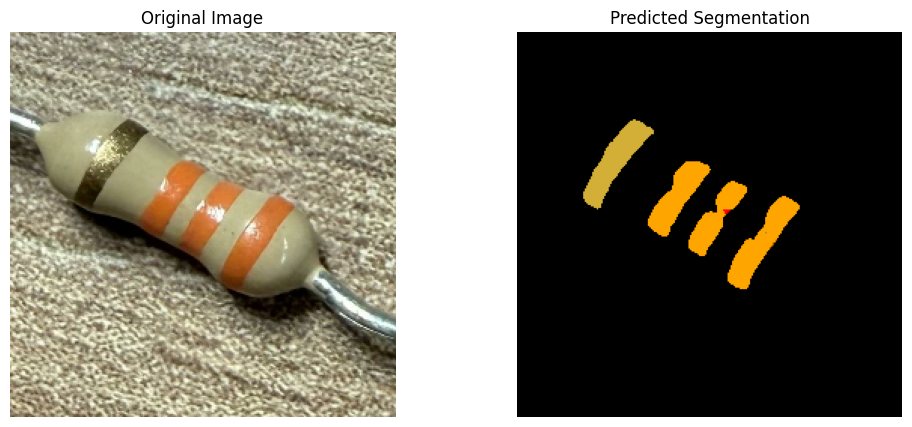

In [16]:
test_image("/content/33kohm.jpg")


In [17]:
from pillow_heif import HeifFile
from PIL import Image

input_path = "/content/3.9kohm.HEIC"
output_path = "/content/3.9kohm.jpg"

# Read HEIC file
heif_file = HeifFile(input_path)
image = heif_file.to_pillow()

# Save as a JPEG
image.save(output_path, format="JPEG")

print("Converted to:", output_path)

Converted to: /content/3.9kohm.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


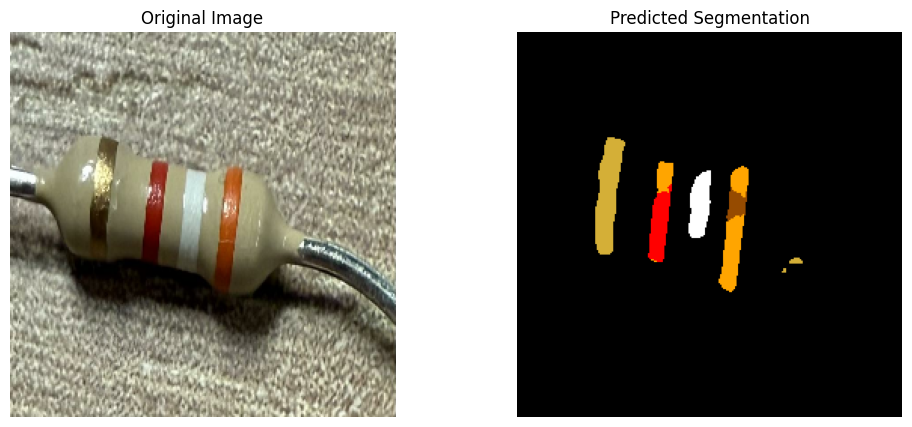

In [18]:
test_image("/content/3.9kohm.jpg")


In [20]:
from pillow_heif import HeifFile
from PIL import Image

input_path = "/content/270kohm.HEIC"
output_path = "/content/270kohm.jpg"

# Read HEIC file
heif_file = HeifFile(input_path)
image = heif_file.to_pillow()

# Save as a JPEG
image.save(output_path, format="JPEG")

print("Converted to:", output_path)

Converted to: /content/270kohm.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step


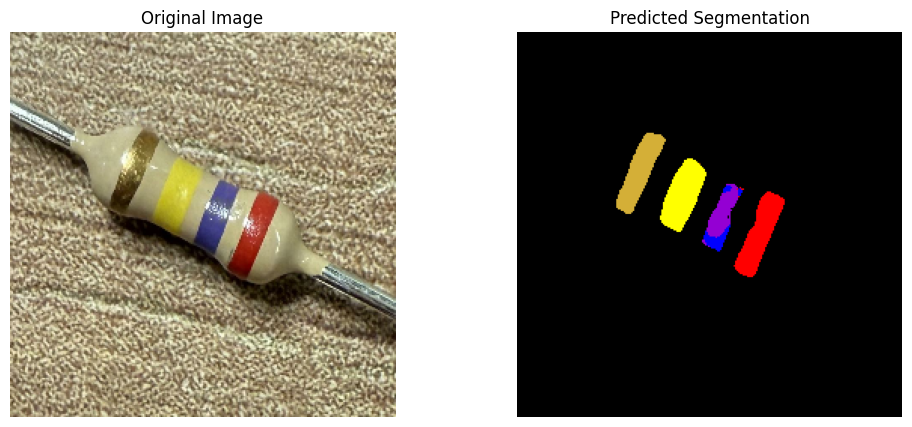

In [21]:
test_image("/content/270kohm.jpg")


In [22]:
from pillow_heif import HeifFile
from PIL import Image

input_path = "/content/27ohm.HEIC"
output_path = "/content/27ohm.jpg"

# Read HEIC file
heif_file = HeifFile(input_path)
image = heif_file.to_pillow()

# Save as a JPEG
image.save(output_path, format="JPEG")

print("Converted to:", output_path)

Converted to: /content/27ohm.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step


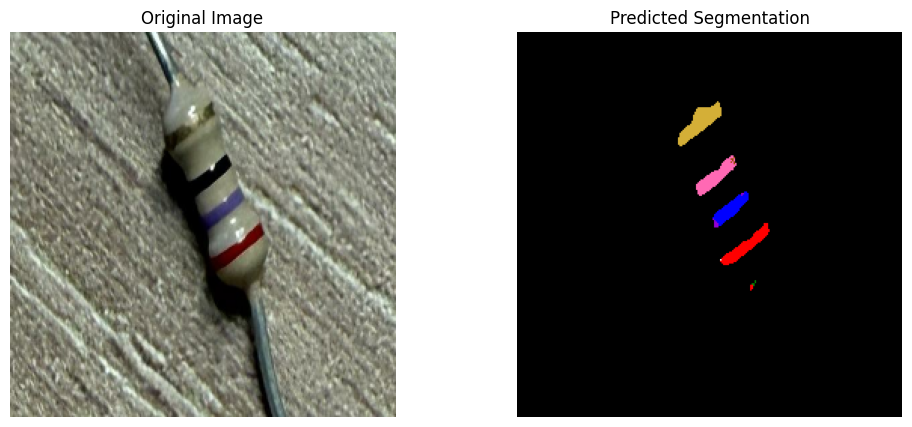

In [23]:
test_image("/content/27ohm.jpg")


In [24]:
from pillow_heif import HeifFile
from PIL import Image

input_path = "/content/33ohm.HEIC"
output_path = "/content/33ohm.jpg"

# Read HEIC file
heif_file = HeifFile(input_path)
image = heif_file.to_pillow()

# Save as a JPEG
image.save(output_path, format="JPEG")

print("Converted to:", output_path)

Converted to: /content/33ohm.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step


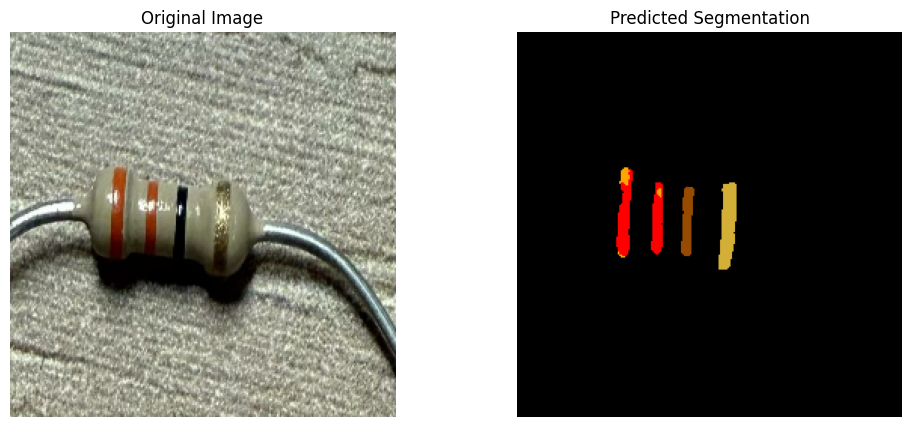

In [25]:
test_image("/content/33ohm.jpg")
